In [186]:
import pandas as pd
import kagglehub
import os

# Download the dataset (unzips to a local directory)
path = kagglehub.dataset_download("awaiskaggler/insurance-csv")

# Get full path to the CSV file inside the downloaded folder
csv_file = os.path.join(path, "insurance.csv")

# Read the CSV file
df = pd.read_csv(csv_file)

# Show first 5 rows
df.head()


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [187]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [188]:
df.shape

(1338, 7)

In [189]:
for col in df.columns:
    print(f"{col} count: {df[col].count()}")
    print(f"{col} unique: {df[col].nunique()}")
    print(f"{col} dtype: {df[col].dtype}")
    print(f"{col} is_numeric_dtype: {pd.api.types.is_numeric_dtype(df[col])}")
    print(f"{col} isnull().sum(): {df[col].isnull().sum()}")
    
    print("-" * 30)


age count: 1338
age unique: 47
age dtype: int64
age is_numeric_dtype: True
age isnull().sum(): 0
------------------------------
sex count: 1338
sex unique: 2
sex dtype: object
sex is_numeric_dtype: False
sex isnull().sum(): 0
------------------------------
bmi count: 1338
bmi unique: 275
bmi dtype: float64
bmi is_numeric_dtype: True
bmi isnull().sum(): 0
------------------------------
children count: 1338
children unique: 6
children dtype: int64
children is_numeric_dtype: True
children isnull().sum(): 0
------------------------------
smoker count: 1338
smoker unique: 2
smoker dtype: object
smoker is_numeric_dtype: False
smoker isnull().sum(): 0
------------------------------
region count: 1338
region unique: 4
region dtype: object
region is_numeric_dtype: False
region isnull().sum(): 0
------------------------------
expenses count: 1338
expenses unique: 1337
expenses dtype: float64
expenses is_numeric_dtype: True
expenses isnull().sum(): 0
------------------------------


In [190]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

In [191]:
print(f"min()         : {df.expenses.min():.2f}")
print(f"max()         : {df.expenses.max():.2f}")
print(f"quantile(.25) : {df.expenses.quantile(0.25):.2f}")
print(f"quantile(.50) : {df.expenses.quantile(0.50):.2f}")
print(f"quantile(.75) : {df.expenses.quantile(0.75):.2f}")
print(f"mean()        : {df.expenses.mean():.2f}")
print(f"median()      : {df.expenses.median():.2f}")

# mode() can return multiple values, so we handle that:
modes = df.expenses.mode()
print(f"mode()        : {', '.join([f'{m:.2f}' for m in modes])}")

print(f"std()      : {df.expenses.std():.2f}")



min()         : 1121.87
max()         : 63770.43
quantile(.25) : 4740.29
quantile(.50) : 9382.03
quantile(.75) : 16639.92
mean()        : 13270.42
median()      : 9382.03
mode()        : 1639.56
std()      : 12110.01


In [192]:
# Detect Outliers (IQR Method)

In [193]:
Q1 = df.expenses.quantile(0.25)
Q3 = df.expenses.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df.expenses < lower_bound) | (df.expenses > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")


Number of outliers: 139


In [194]:
from scipy.stats import kurtosis, skew 

print(f'Skew : {skew(df.expenses)}')
print(f'Skew : {skew(df.expenses, bias="false")}')
print(f'Kurtosis : {kurtosis(df.expenses, bias="false")}')

print(f'Skew : {df.expenses.skew()}')
print(f'Kurtosis : {df.expenses.kurt()}')

Skew : 1.5141797167430497
Skew : 1.5141797167430497
Kurtosis : 1.5958213684180036
Skew : 1.51587966289798
Kurtosis : 1.6062986577747589


# Age Distribution Barchart

In [195]:
print(f'age: min: {df.age.min()}, max:{df.age.max()}')

age: min: 18, max:64


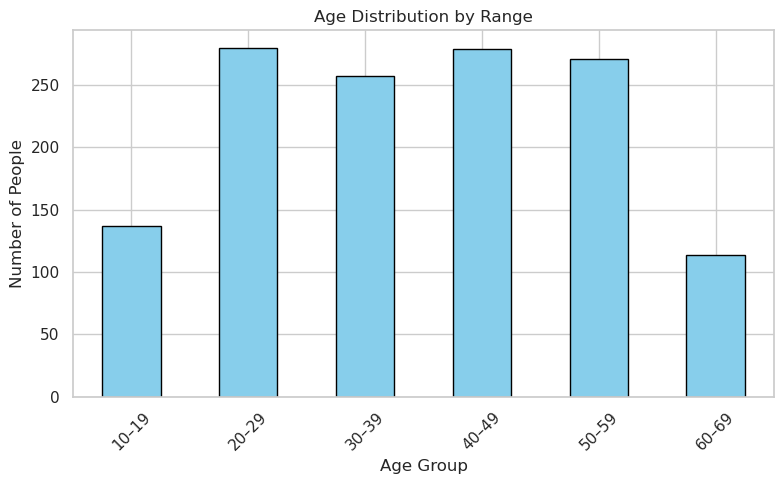

In [196]:
import pandas as pd
import matplotlib.pyplot as plt

# Create age bins (you can customize the ranges)
bins = [10, 20, 30, 40, 50, 60, 70]
labels = ['10–19', '20–29', '30–39', '40–49', '50–59', '60–69']

# Cut age into ranges
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Count number of records in each group
age_counts = df['age_group'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8, 5))
age_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Age Distribution by Range')
plt.xlabel('Age Group')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Pie Chart for sex Column

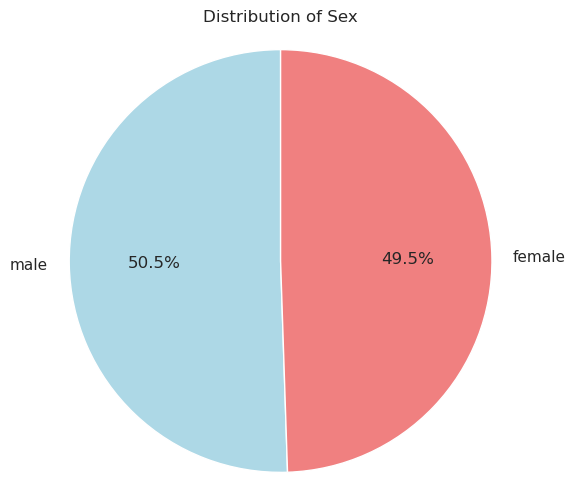

In [197]:
import pandas as pd
import matplotlib.pyplot as plt

# Count values
sex_counts = df['sex'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title('Distribution of Sex')
plt.axis('equal')  # Equal aspect ratio ensures the pie is a circle
plt.show()


# BMI (Body Mass Index)

In [198]:
df.bmi.unique()

array([27.9, 33.8, 33. , 22.7, 28.9, 25.7, 33.4, 27.7, 29.8, 25.8, 26.2,
       26.3, 34.4, 39.8, 42.1, 24.6, 30.8, 23.8, 40.3, 35.3, 36. , 32.4,
       34.1, 31.9, 28. , 23.1, 32.8, 17.4, 36.3, 35.6, 28.6, 28.3, 36.4,
       20.4, 20.8, 36.7, 39.9, 26.6, 36.6, 21.8, 37.1, 37.3, 38.7, 34.8,
       24.5, 35.2, 33.6, 28.7, 37. , 31.8, 31.7, 22.9, 27.4, 33.7, 24.7,
       25.9, 22.4, 39.1, 36.2, 24. , 24.8, 28.5, 28.1, 32. , 34. , 29.6,
       35.5, 26.9, 38.3, 37.6, 41.2, 31.2, 27.2, 27. , 39.5, 31.3, 20. ,
       19.3, 31.6, 25.5, 30.1, 29.9, 27.5, 28.4, 30.9, 35.1, 29.7, 35.7,
       32.2, 49.1, 23.4, 29. , 31.4, 33.9, 28.8, 37.4, 17.8, 34.7, 26.5,
       22. , 35.9, 25.6, 25.2, 32.5, 25.3, 38.8, 30.5, 37.7, 24.1, 24.4,
       27.8, 36.9, 39.6, 28.2, 33.2, 18.9, 41.5, 30.3, 16. , 33.3, 29.2,
       26.4, 30.7, 41.9, 32.1, 30.6, 18.1, 39.3, 36.1, 22.3, 26.7, 23.2,
       38.1, 22.2, 38.4, 29.1, 22.1, 26.8, 30. , 20.9, 17.3, 34.2, 25.4,
       40.2, 24.3, 42.4, 19.8, 30.2, 29.4, 27.6, 20

In [199]:
print(f'age: min: {df.bmi.min()}, max:{df.bmi.max()}')

age: min: 16.0, max:53.1


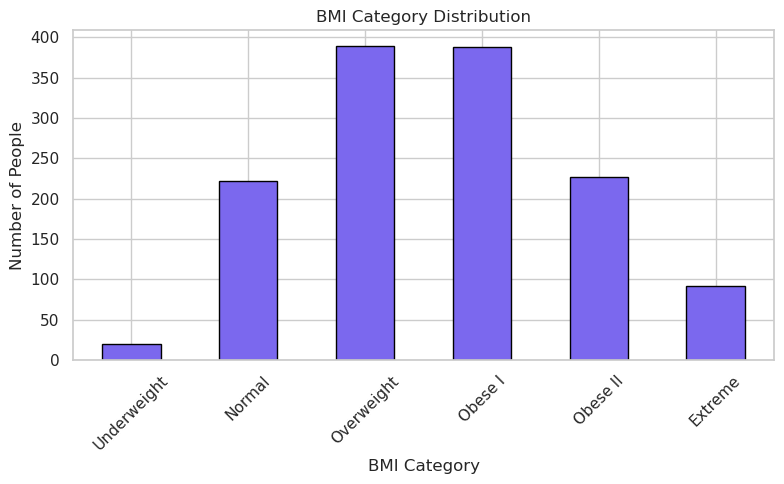

In [200]:
import pandas as pd
import matplotlib.pyplot as plt

# Define BMI bins (you can customize)
bins = [10, 18.5, 25, 30, 35, 40, 60]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II', 'Extreme']
df['bmi_group'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)

# Count number of people in each BMI category
bmi_counts = df['bmi_group'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8, 5))
bmi_counts.plot(kind='bar', color='mediumslateblue', edgecolor='black')
plt.title('BMI Category Distribution')
plt.xlabel('BMI Category')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Pie Chart for smoker Column

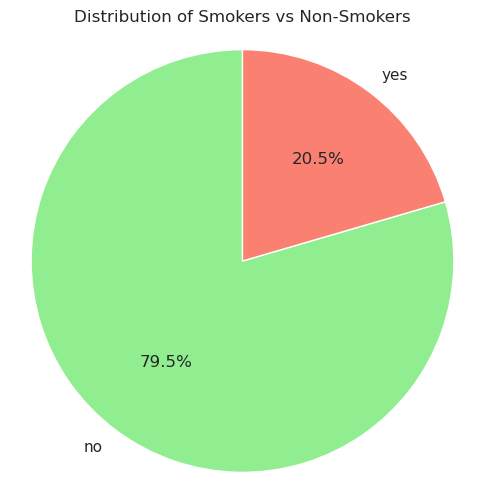

In [201]:
import pandas as pd
import matplotlib.pyplot as plt

# Count values
smoker_counts = df['smoker'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(smoker_counts, 
        labels=smoker_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['lightgreen', 'salmon'])
plt.title('Distribution of Smokers vs Non-Smokers')
plt.axis('equal')  # Makes the pie chart circular
plt.show()


In [202]:
print(f'expense: min: {df.expenses.min()}, max:{df.expenses.max()}')

expense: min: 1121.87, max:63770.43


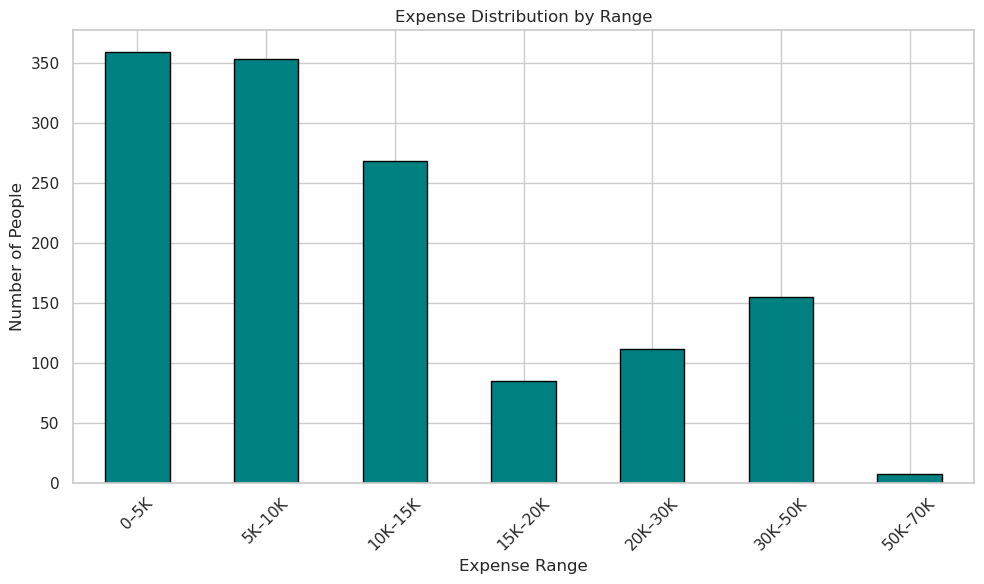

In [203]:
import pandas as pd
import matplotlib.pyplot as plt

# Create bins for expenses
bins = [0, 5000, 10000, 15000, 20000, 30000, 50000, 70000]
labels = ['0–5K', '5K–10K', '10K–15K', '15K–20K', '20K–30K', '30K–50K', '50K–70K']
df['expense_group'] = pd.cut(df['expenses'], bins=bins, labels=labels, right=False)

# Count number of people in each expense group
expense_counts = df['expense_group'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(10, 6))
expense_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Expense Distribution by Range')
plt.xlabel('Expense Range')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Region-wise Pie Chart

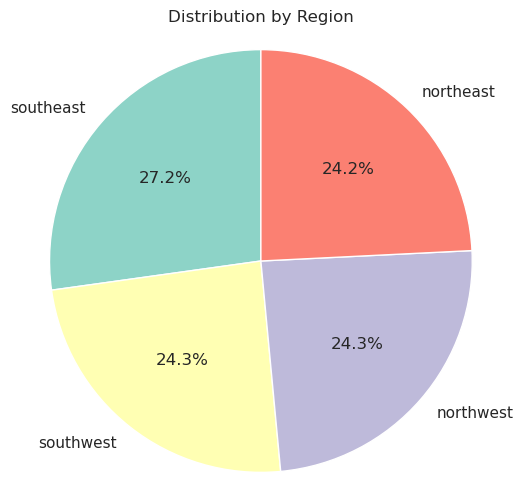

In [204]:
import pandas as pd
import matplotlib.pyplot as plt

# Count number of people in each region
region_counts = df['region'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(region_counts, 
        labels=region_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=plt.cm.Set3.colors)  # Set3 gives good distinct colors
plt.title('Distribution by Region')
plt.axis('equal')  # Ensures pie is a circle
plt.show()


# Heatmap

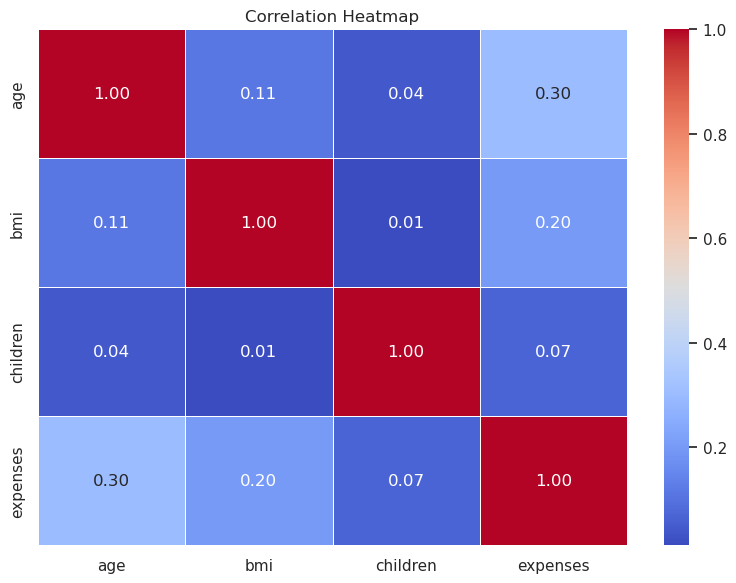

In [205]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.corr(numeric_only=True)  # Only includes numeric columns

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## Top Correlations from Heatmap

In [206]:
import pandas as pd

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Unstack the matrix to get pairs
corr_pairs = corr_matrix.unstack()

# Remove self-correlations (correlation of a variable with itself = 1.0)
filtered_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Drop duplicate pairs (since correlation matrix is symmetric)
unique_pairs = filtered_pairs.groupby([frozenset(i) for i in filtered_pairs.index]).first()

# Sort descending by correlation value
top_corr = unique_pairs.sort_values(ascending=False)

# Display top N (e.g., top 5)
print(top_corr.head(5))


(age, expenses)         0.299008
(bmi, expenses)         0.198576
(bmi, age)              0.109341
(children, expenses)    0.067998
(children, age)         0.042469
dtype: float64


## Outliers Removal

In [207]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Iterative removal of outliers
while True:
    Q1 = df['expenses'].quantile(0.25)
    Q3 = df['expenses'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    new_df = df[(df['expenses'] >= lower) & (df['expenses'] <= upper)]

    if new_df.shape[0] == df.shape[0]:
        break
    df = new_df


# Find outliers
outliers = df[(df.expenses < lower_bound) | (df.expenses > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 0


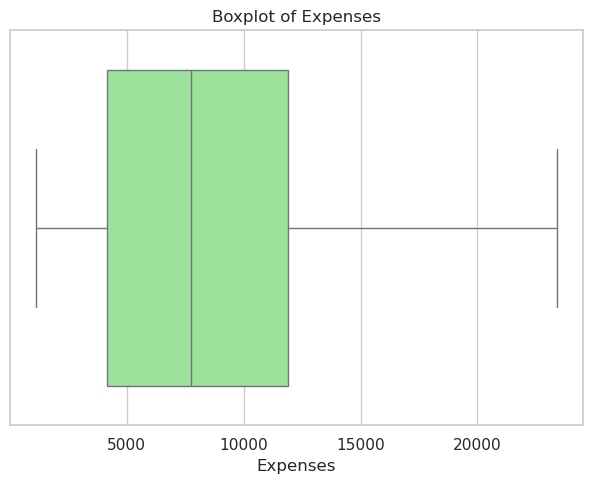

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style
sns.set(style="whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(12, 5))


# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df.expenses, color='lightgreen')
plt.title('Boxplot of Expenses')
plt.xlabel('Expenses')

# Show the plot
plt.tight_layout()
plt.show()

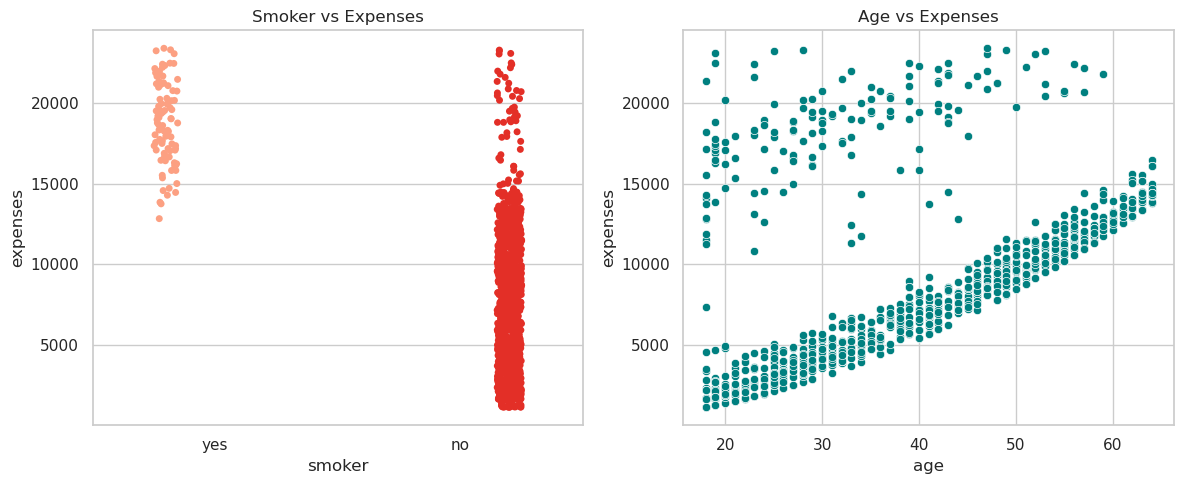

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Smoker vs expenses (corrected to avoid FutureWarning)
plt.subplot(1, 2, 1)
sns.stripplot(data=df, x='smoker', y='expenses', hue='smoker', palette='Reds', dodge=True, legend=False)
plt.title('Smoker vs Expenses')

# Age vs expenses
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='age', y='expenses', color='teal')
plt.title('Age vs Expenses')

plt.tight_layout()
plt.show()
